<a href="https://colab.research.google.com/github/jasper99tai77-afk/BAPortfolio/blob/main/Portfolio_Stroke_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

# Data Preprocessing

For data cleaning, we omit the rows that have missing values and create dummy variables for categorical predictors.

Column description:


1) gender: "Male", "Female" or "Other"
2) age: age of the patient
3) hypertension: 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
4) heart_disease: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
5) ever_married: "No" or "Yes"
6) work_type: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
7) Residence_type: "Rural" or "Urban"
8) avg_glucose_level: average glucose level in blood
9) bmi: body mass index
10) smoking_status: "formerly smoked", "never smoked", "smokes" or "Unknown"
11) stroke: 1 if the patient had a stroke or 0 if not

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/JaperTai77/data-modified/main/healthcare-dataset-stroke-data.csv')
df = df.drop(columns = 'id')
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
# remove null value
df = df[df.gender != 'Other'].dropna()
raw_data = df.copy()

# create dummy variables
cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
prefixes = {'gender': '', 'ever_married': 'marry', 'work_type': 'job', 'Residence_type': 'neigh', 'smoking_status': 'smoke'}

df = pd.get_dummies(df, columns=cols, prefix=prefixes, drop_first=True)

df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,_Male,marry_Yes,job_Never_worked,job_Private,job_Self-employed,job_children,neigh_Urban,smoke_formerly smoked,smoke_never smoked,smoke_smokes
0,67.0,0,1,228.69,36.6,1,True,True,False,True,False,False,True,True,False,False
2,80.0,0,1,105.92,32.5,1,True,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,True,False,False,True,False,False,False,True,False
5,81.0,0,0,186.21,29.0,1,True,True,False,True,False,False,True,True,False,False


In [8]:
df.shape

(4908, 16)

After cleaning our data, we have dwindled down our number of observations from 5110 to 4908.

# EDA

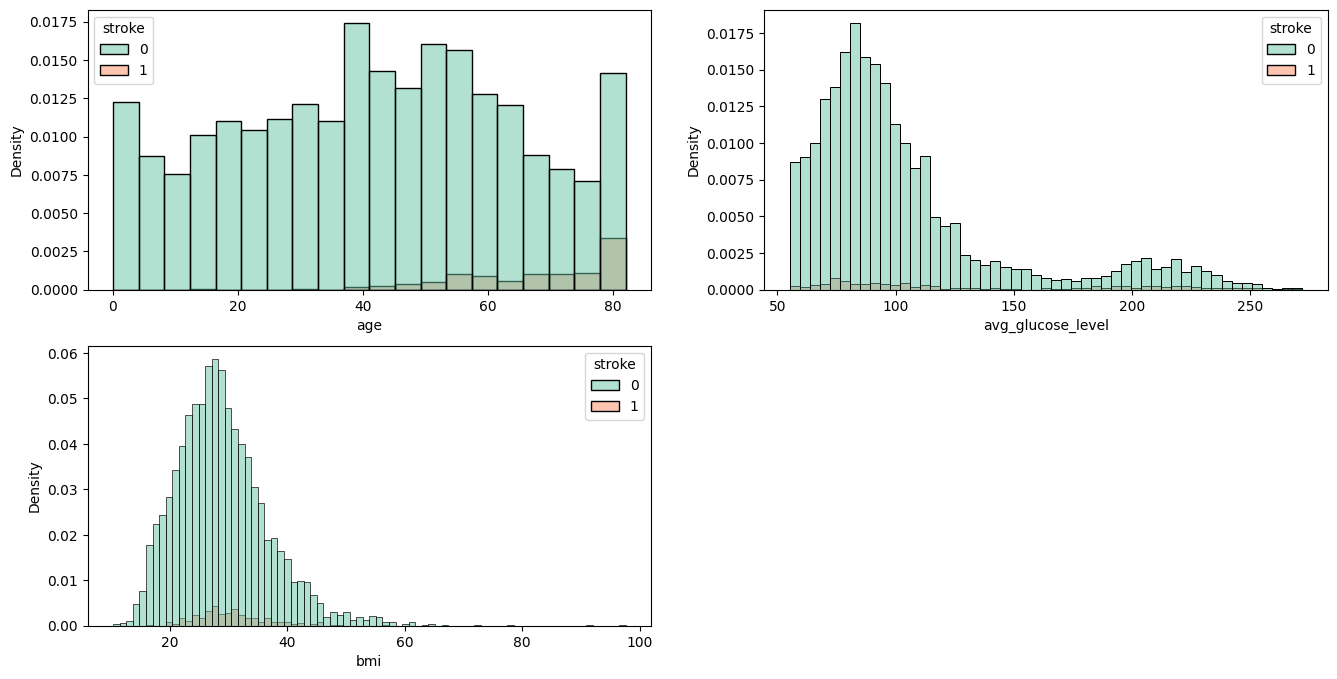

In [14]:
# Numeric columns for distribution analysis
plt.figure(figsize = (16,8))
col = df.select_dtypes(['float']).columns
j = 1
for c in col:
    plt.subplot(2,2,j)
    sns.histplot(x = c, hue = 'stroke', data = df, stat = 'density', palette = 'Set2')
    j = j+1
plt.show()

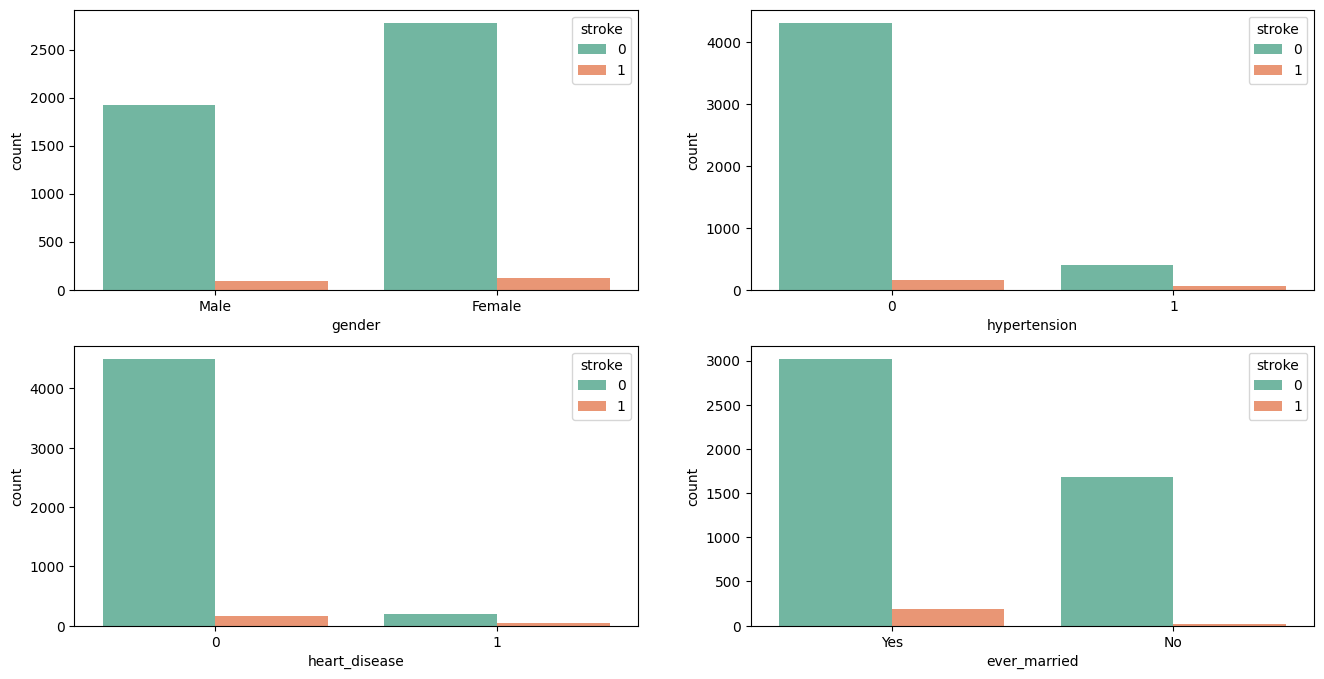

In [15]:
# Visualize categorical columns
plt.figure(figsize = (16,8))
col = raw_data.select_dtypes(exclude = ['float']).columns[:4]
j = 1
for c in col:
    plt.subplot(2,2,j)
    sns.countplot(x = c, hue = 'stroke',data = raw_data, palette = 'Set2')
    j = j+1
plt.show()

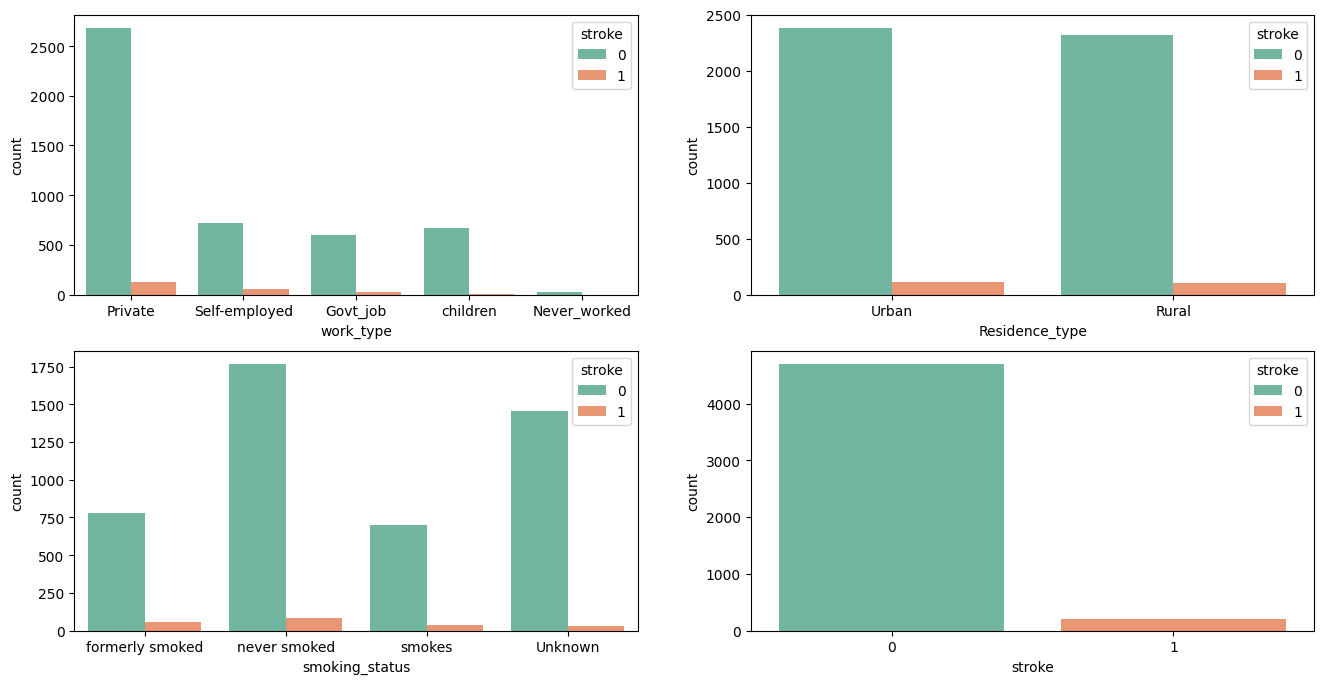

In [16]:
# Visualize categorical columns
plt.figure(figsize = (16,8))
col = raw_data.select_dtypes(exclude = ['float']).columns[4:]
j = 1
for c in col:
    plt.subplot(2,2,j)
    sns.countplot(x = c, hue = 'stroke',data = raw_data, palette = 'Set2')
    j = j+1
plt.show()

From the visualization, we observe older patients are more likely to have a stroke than younger patients. Patients with higher glucose levels are also more likely to get a stroke. We also see that the variable stroke is unevenly distributed, so we have an unbalanced dataset.

# Modeling

Our stroke dataset is unbalanced, more than 95% of the patients didn't have a stroke. Therefore, we split the dataset manually, so there are patients with stroke in both training and testing sets.

In [6]:
# split data to training and testing with undersampling. The ratio for with stoke and no stroke is 1:2.
X = df.drop(columns=['stroke'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=7)
rus = RandomUnderSampler(sampling_strategy={1: 150, 0: 300}, random_state=7)

X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

In [7]:
# scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

In [8]:
print(X_train_res.shape)
print(X_test.shape)

(450, 15)
(982, 15)


 Due to undersampling, there is less data in training set.

## Logistic Regression

In [9]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res,y_train_res)

ypred = lr.predict(X_test)

print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

           0       0.98      0.84      0.90       940
           1       0.13      0.52      0.20        42

    accuracy                           0.82       982
   macro avg       0.55      0.68      0.55       982
weighted avg       0.94      0.82      0.87       982



In [10]:
log_con = confusion_matrix(y_test,ypred)

## Support Vector Machine

In [42]:
svm = SVC()
cv = StratifiedShuffleSplit(n_splits=3, test_size=0.2)
Cs = [0.01, 0.1, 1]
gammas = [0.01, 0.1, 1]
kernels = ['linear','poly','sigmoid']
degrees = [1,2,3]
param_grid = dict(gamma=gammas, C=Cs, kernel = kernels, degree = degrees)

grid_cv = GridSearchCV(svm, param_grid=param_grid, cv=cv)
grid_cv.fit(X_train_res,y_train_res)

print(grid_cv.best_params_)

{'C': 1, 'degree': 1, 'gamma': 0.01, 'kernel': 'linear'}


In [43]:
ypred = grid_cv.predict(X_test)
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

           0       0.98      0.82      0.89       940
           1       0.12      0.55      0.20        42

    accuracy                           0.81       982
   macro avg       0.55      0.68      0.54       982
weighted avg       0.94      0.81      0.86       982



In [44]:
svm_con = confusion_matrix(y_test,ypred)

## Decision Tree

In [45]:
dtc = DecisionTreeClassifier()

cv = StratifiedShuffleSplit(n_splits=3, test_size=0.2)

crit = ['gini','entropy']
maxdep = [5,10,15]
maxleaf = [10,50,100]

param_grid = {'criterion':crit, 'max_depth':maxdep, 'max_leaf_nodes':maxleaf}
gs_inst = GridSearchCV(dtc,param_grid=param_grid,cv=cv)
gs_inst.fit(X_train_res,y_train_res)

print(gs_inst.best_params_)

{'criterion': 'entropy', 'max_depth': 10, 'max_leaf_nodes': 10}


In [47]:
ypred = gs_inst.predict(X_test)
print(classification_report(y_test,ypred))
tree_con = confusion_matrix(y_test,ypred)

              precision    recall  f1-score   support

           0       0.97      0.87      0.92       940
           1       0.13      0.43      0.20        42

    accuracy                           0.86       982
   macro avg       0.55      0.65      0.56       982
weighted avg       0.94      0.86      0.89       982



## Random Forest

In [22]:
rft = RandomForestClassifier()
cv = StratifiedShuffleSplit(n_splits=3, test_size=0.2)
ne = [50,100]
c = ['gini', 'entropy']
max_depth = [100,200]
min_samples_leaf = [1,10]

param_grid = {'n_estimators': ne, 'max_depth': max_depth,'min_samples_leaf': min_samples_leaf, 'criterion' : c}
gs_inst = GridSearchCV(rft, param_grid= param_grid, cv =cv)
gs_inst.fit(X_train_res,y_train_res)

print(gs_inst.best_params_)

{'criterion': 'gini', 'max_depth': 100, 'min_samples_leaf': 1, 'n_estimators': 50}


In [23]:
ypred = gs_inst.predict(X_test)
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

           0       0.97      0.84      0.90       940
           1       0.10      0.40      0.16        42

    accuracy                           0.82       982
   macro avg       0.54      0.62      0.53       982
weighted avg       0.93      0.82      0.87       982



In [24]:
rf_con = confusion_matrix(y_test,ypred)

## K-nearest Neighbor

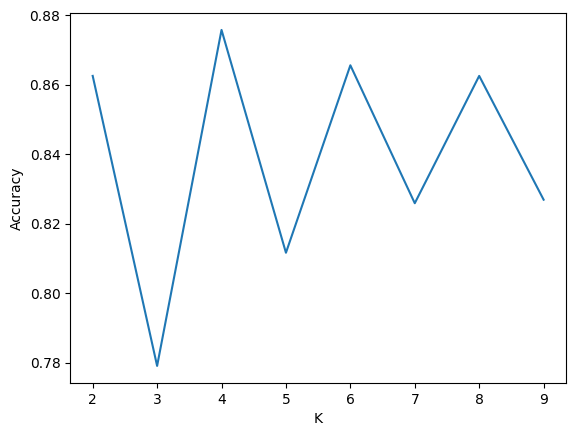

In [26]:
scoreList = []
for i in range(2,10):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_train_res,y_train_res)
    ypred = knn.predict(X_test)
    scoreList.append(accuracy_score(y_test,ypred))

plt.plot(range(2,10), scoreList)
plt.xticks(np.arange(2,10,1))
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

In [27]:
knn = KNeighborsClassifier(n_neighbors = 4)
knn.fit(X_train_res,y_train_res)
ypred = knn.predict(X_test)
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

           0       0.96      0.91      0.93       940
           1       0.08      0.19      0.12        42

    accuracy                           0.88       982
   macro avg       0.52      0.55      0.52       982
weighted avg       0.92      0.88      0.90       982



In [28]:
knn_con = confusion_matrix(y_test,ypred)

## Gradient Boosting

In [30]:
gb = GradientBoostingClassifier(n_estimators=100)
gb.fit(X_train_res,y_train_res)
ypred = gb.predict(X_test)
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

           0       0.97      0.82      0.89       940
           1       0.09      0.40      0.15        42

    accuracy                           0.81       982
   macro avg       0.53      0.61      0.52       982
weighted avg       0.93      0.81      0.86       982



In [31]:
gbo_con = confusion_matrix(y_test,ypred)

## Neural Network

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

In [34]:
model = Sequential()
model.add(Dense(15,activation = 'relu'))
model.add(Dropout(0.25))
model.add(Dense(7,activation = 'relu'))
model.add(Dropout(0.25))
model.add(Dense(1,activation = 'sigmoid'))
model.compile(loss = 'binary_crossentropy',optimizer = 'rmsprop',metrics=['accuracy'])

earstop = EarlyStopping(monitor = 'val_loss', mode ='min', verbose = 1, patience = 10)
model.fit(x = X_train_res, y = y_train_res, epochs = 200, validation_data=(X_test,y_test), callbacks = [earstop])

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.4929 - loss: 0.7241 - val_accuracy: 0.7566 - val_loss: 0.5819
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5051 - loss: 0.6791 - val_accuracy: 0.8493 - val_loss: 0.5368
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5833 - loss: 0.7003 - val_accuracy: 0.8870 - val_loss: 0.5180
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.6112 - loss: 0.6451 - val_accuracy: 0.9134 - val_loss: 0.4983
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5643 - loss: 0.6539 - val_accuracy: 0.9338 - val_loss: 0.4718
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5877 - loss: 0.6428 - val_accuracy: 0.9430 - val_loss: 0.4524
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6130 - loss: 0.6256 - val_accuracy: 0.9409 - val_loss: 0.4508
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5968 - loss: 0.6367 - val_accuracy: 0

<Axes: >

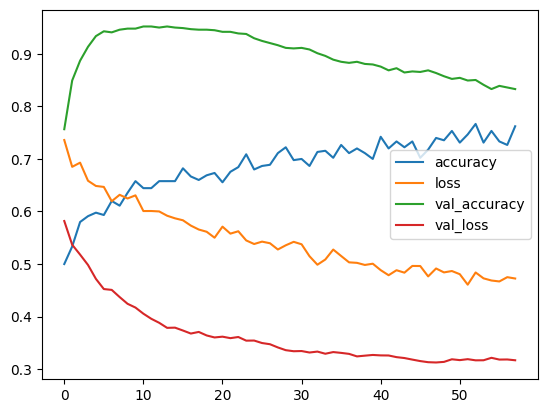

In [35]:
loss = pd.DataFrame(model.history.history)
loss.plot()

In [37]:
ypred_probs = model.predict(X_test)
ypred = (ypred_probs > 0.5).astype(int)
print(classification_report(y_test,ypred))

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
              precision    recall  f1-score   support

           0       0.97      0.85      0.91       940
           1       0.12      0.48      0.20        42

    accuracy                           0.83       982
   macro avg       0.55      0.66      0.55       982
weighted avg       0.94      0.83      0.88       982



In [38]:
nt_con = confusion_matrix(y_test,ypred)

# Summary

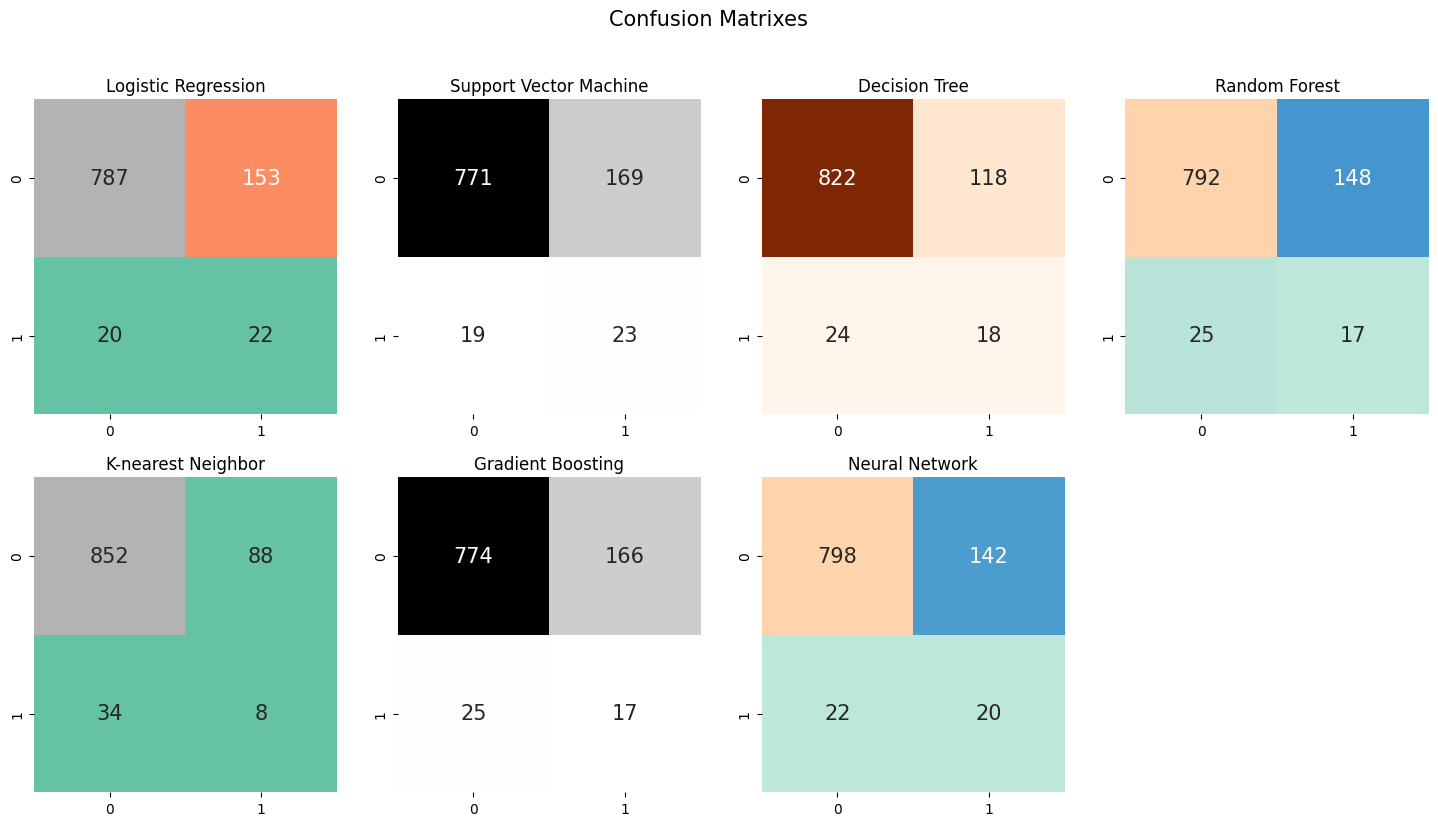

In [48]:
plt.figure(figsize=(18,9))

plt.suptitle("Confusion Matrixes",fontsize=15)
plt.subplots_adjust(wspace = 0.2, hspace= 0.2)

plt.subplot(2,4,1)
plt.title("Logistic Regression")
sns.heatmap(log_con,annot=True,cmap="Set2",fmt="d",cbar=False, annot_kws={"size": 15})

plt.subplot(2,4,2)
plt.title("Support Vector Machine")
sns.heatmap(svm_con,annot=True,cmap="binary",fmt="d",cbar=False, annot_kws={"size": 15})

plt.subplot(2,4,3)
plt.title("Decision Tree")
sns.heatmap(tree_con,annot=True,cmap="Oranges",fmt="d",cbar=False, annot_kws={"size": 15})

plt.subplot(2,4,4)
plt.title("Random Forest")
sns.heatmap(rf_con,annot=True,cmap="icefire",fmt="d",cbar=False, annot_kws={"size": 15})

plt.subplot(2,4,5)
plt.title("K-nearest Neighbor")
sns.heatmap(knn_con,annot=True,cmap="Set2",fmt="d",cbar=False, annot_kws={"size": 15})

plt.subplot(2,4,6)
plt.title("Gradient Boosting")
sns.heatmap(gbo_con,annot=True,cmap="binary",fmt="d",cbar=False, annot_kws={"size": 15})

plt.subplot(2,4,7)
plt.title("Neural Network")
sns.heatmap(nt_con,annot=True,cmap="icefire",fmt="d", cbar=False, annot_kws={"size": 15})

plt.show()

Based on these matrixes and the f1 score, the SVM is the best because it identifies the highest number of actual stroke cases and have less misses on potential stroke patients. It produced 169 false positives, illustrating a trade-off between Recall and Precision. In a medical context, catching the disease is usually the top priority. Therefore, we are fine with the 169 false positive.